In [151]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [152]:
from dask.distributed import Client, LocalCluster

client = Client() # Note that `memory_limit` is the limit **per worker**.
# n_workers=4,
#                 threads_per_worker=1,
#                 memory_limit='3GB'
client # If you click the dashboard link in the output, you can monitor real-time progress and get other cool visualizations.

/home/amcdona4/miniconda3/envs/usrp_radar/lib/python3.11/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 41779 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:41779/status,
Dashboard: http://127.0.0.1:41779/status,Workers: 4
Total threads: 12,Total memory: 15.30 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41637,Workers: 0
Dashboard: http://127.0.0.1:41779/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:38331,Total threads: 3
Dashboard: http://127.0.0.1:41775/status,Memory: 3.82 GiB
Nanny: tcp://127.0.0.1:37007,


In [153]:
import copy
import sys
import xarray as xr
import numpy as np
import dask.array as da

import matplotlib.pyplot as plt
import hvplot.xarray
import scipy.constants

sys.path.append("..")
import processing_dask as pr
import plot_dask
import processing as old_processing

sys.path.append("../../preprocessing/")
from generate_chirp import generate_chirp

In [154]:
plt.rcParams.update({'font.size': 12})

### Open and resave file

In [155]:
# file path to data and configs
prefix = "../../data/20260305_133508"

# resave data as zarr for dask processing
zarr_base_location="../../data"
zarr_path = pr.save_radar_data_to_zarr(prefix, zarr_base_location=zarr_base_location)

# open zarr file, adjust chunk size to be 10 MB - 1 GB based on sample rate/bit depth
raw = xr.open_zarr(zarr_path, chunks='auto')

/home/amcdona4/miniconda3/envs/usrp_radar/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


### Enter processing parameters

In [156]:
# ZERO_SAMPLE_IDX = 0  # B205mini, fs = 56 MHz
ZERO_SAMPLE_IDX = 160 # B210, fs = 30 MHz

NSTACK = 1  # number of pulses to stack

MODIFY_RX_WINDOW = False  # set to true if you want to window the reference chirp only on receive, false uses ref chirp as transmitted in config file
RX_WINDOW = "rectangular"  # what you want to change the rx window to if modify_rx_window is true

# dielectric_constant = 3.17 # ice (air = 1, 66% velocity coax = 2.2957)
# dielectric_constant = 2.2957 # COAX (air = 1, 66% velocity coax = 2.2957)
DIELECTRIC_CONSTANT = 1  # air
SIG_SPEED = scipy.constants.c / np.sqrt(DIELECTRIC_CONSTANT)

### Generate reference chirp

In [157]:
if MODIFY_RX_WINDOW:
    config = copy.deepcopy(raw.config)
    config['GENERATE']['window'] = RX_WINDOW
else:
    config = raw.config

chirp_ts, ref_chirp = generate_chirp(config)

### View raw pulse in time domain to check for clipping

In [158]:
single_pulse_raw = raw.radar_data[{'pulse_idx': 1}].compute()
plot1 = np.real(single_pulse_raw).hvplot.line(x='fast_time', color='red') * np.imag(single_pulse_raw).hvplot.line(x='fast_time')

plot1 = plot1.opts(xlabel='Fast Time (s)', ylabel='Raw Amplitude')
plot1

:Overlay
   .Curve.I  :Curve   [fast_time]   (radar_data)
   .Curve.II :Curve   [fast_time]   (radar_data)

### Clean and stack data

In [159]:
stacked = pr.fill_errors(raw, error_fill_value=0.0) # fill receiver errors with 0s

stacked = pr.stack(stacked, NSTACK) # stack 

### Pulse compress data

In [160]:
# compressed = pr.pulse_compress(stacked, ref_chirp,
#                                fs=stacked.config['GENERATE']['sample_rate'],
#                                zero_sample_idx=ZERO_SAMPLE_IDX,
#                                signal_speed=SIG_SPEED)

# compressed_power = xr.apply_ufunc(
#     lambda x: 20*np.log10(np.abs(x)),
#     compressed,
#     dask="parallelized"
# )

### View 2D pulse compressed data (radargram)

In [161]:
# # USING MATPLOTLIB (sometimes takes a while)
# fig, ax = plt.subplots(1,1, figsize=(10,6), facecolor='white')

# p = ax.pcolormesh(compressed_power.slow_time, compressed_power.reflection_distance, compressed_power.radar_data.transpose(), shading='auto', cmap='inferno')
# ax.invert_yaxis()
# clb = fig.colorbar(p, ax=ax)
# clb.set_label('Return Power (dB)')
# ax.set_xlabel('Slow Time (s)')
# ax.set_ylabel('Distance to Reflector (m)')
# # relevant options: ax.set_ylim=(100,-50), ax.set_xlim=(0, 1), vmin=-90, vmax=40
# ax.set_ylim(100, -50)

### Apply FFT to data

In [162]:
radar_fft_data = pr.radar_fft(
    stacked,
    ref_chirp,
    fs=stacked.config["GENERATE"]["sample_rate"],
    zero_sample_idx=ZERO_SAMPLE_IDX,
    signal_speed=SIG_SPEED,
)

fft_power = xr.apply_ufunc(
    lambda x: 20*np.log10(np.abs(x)),
    radar_fft_data,
    dask="parallelized"
).compute()

/home/amcdona4/miniconda3/envs/usrp_radar/lib/python3.11/site-packages/dask/array/utils.py:105: ComplexWarning: Casting complex values to real discards the imaginary part
  meta = meta.astype(dtype)


### View 1D FFT data

In [163]:
plot1D = fft_power.radar_data[20,:].hvplot.line()
plot1D = plot1D * fft_power.radar_data[-1,:].hvplot.line()
# relevant options: xlim(-80,1000)

plot1D = plot1D.opts(xlabel='Reflection Distance (m)', ylabel='Return Power (dB)')
# plot1D.opts(xlim=(-50,200), ylim=(-120, -40), show_grid=True)
plot1D

:Overlay
   .Curve.I  :Curve   [reflection_distance]   (radar_data)
   .Curve.II :Curve   [reflection_distance]   (radar_data)

### View 2D FFT data (radargram)

Text(0, 0.5, 'Slow Time (s)')

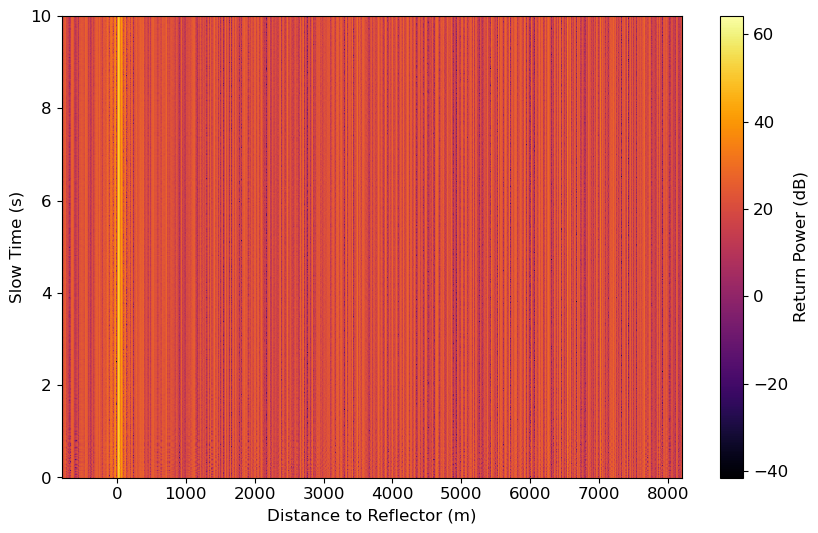

In [164]:
# USING MATPLOTLIB (sometimes takes a while)
fig, ax = plt.subplots(1,1, figsize=(10,6), facecolor='white')

# [ZERO_SAMPLE_IDX:len(fft_power.reflection_distance)/2]



p = ax.pcolormesh( fft_power.reflection_distance, fft_power.slow_time, fft_power.radar_data, shading='nearest', cmap='inferno')
clb = fig.colorbar(p, ax=ax)
clb.set_label('Return Power (dB)')
ax.set_xlabel('Distance to Reflector (m)')
ax.set_ylabel('Slow Time (s)')
# relevant options: ax.set_ylim=(100,-50), ax.set_xlim=(0, 1), vmin=-90, vmax=40
# ax.set_ylim(100, -50)

1800
(1000, 900)


Text(0, 0.5, 'Slow Time (s)')

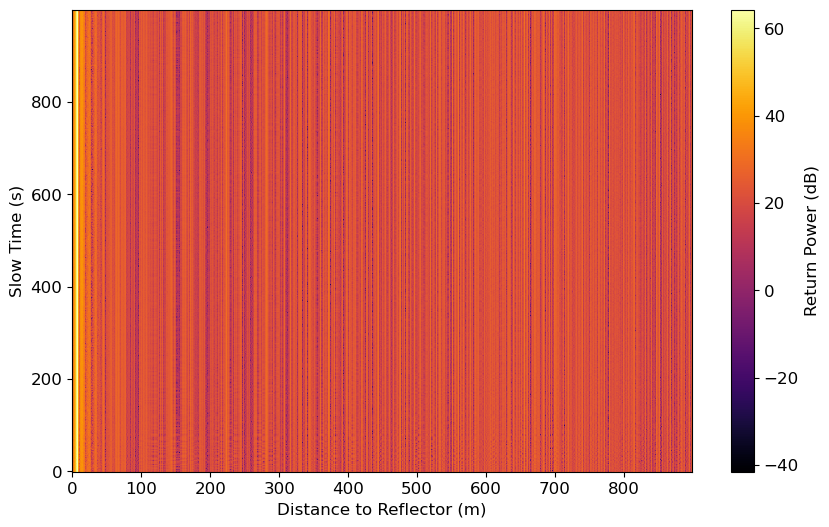

In [165]:
fig, ax = plt.subplots(1,1, figsize=(10,6), facecolor='white')

print(len(fft_power.reflection_distance))

fft_graph = fft_power.radar_data[:, ZERO_SAMPLE_IDX:int(len(fft_power.reflection_distance) / 2) + ZERO_SAMPLE_IDX]

print(fft_graph.shape)

p = ax.pcolormesh( fft_graph, shading='nearest', cmap='inferno')
clb = fig.colorbar(p, ax=ax)
clb.set_label('Return Power (dB)')
ax.set_xlabel('Distance to Reflector (m)')
ax.set_ylabel('Slow Time (s)')

### View spectrogram of stacked data

In [166]:
inpt = raw
inpt["radar_data"].shape

(1800, 1000)

In [167]:
num_presums = raw.attrs["config"]["CHIRP"]["num_presums"]

In [168]:
# data = stacked["radar_data"].to_numpy()
n = 1
normalize = True

pulse = pr.stack(inpt, n)[{'pulse_idx':200}]["radar_data"].to_numpy()

f, t, S = scipy.signal.spectrogram(
    pulse,
    fs=raw.attrs["config"]["GENERATE"]["sample_rate"],
    window='flattop',
    nperseg=128,
    noverlap=64,
    scaling='density', mode='psd',
    return_onesided=False
)

if normalize:
    S /= np.max(S)

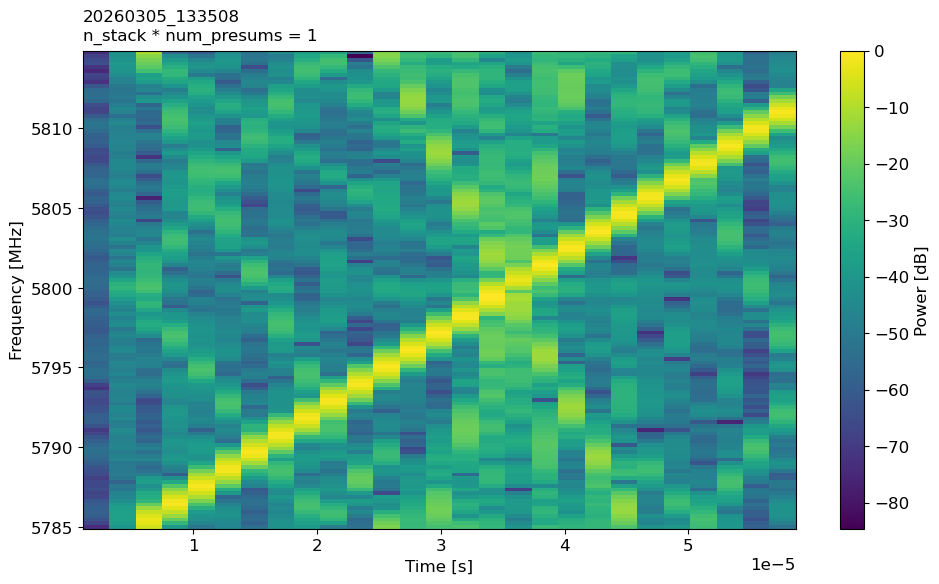

In [169]:
fig, ax = plt.subplots(facecolor='white', figsize=(10,6))
freq_mhz = (np.fft.fftshift(f) + raw.attrs['config']['RF0']['freq']) / 1e6
pcm = ax.pcolormesh(t, freq_mhz, 10*np.log10(np.abs(np.fft.fftshift(S, axes=0))), shading='nearest') #  vmin=-420, vmax=-200
clb = fig.colorbar(pcm, ax=ax)
clb.set_label('Power [dB]')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Frequency [MHz]')
#ax.set_title(f"Spectrogram of received data with n_stack={n}")
ax.text(0, 1.05, prefix.split("/")[-1] + "\n" + f"n_stack * num_presums = {n * num_presums}", horizontalalignment='left', verticalalignment='center', transform=ax.transAxes, fontdict={'size': 12})
fig.tight_layout()
plt.show()

In [170]:
fig.savefig(f"orca_paper/outputs/{raw.basename}_ft_spectrogram_n{n}.png", dpi=300)

### View Power Spectrum of All Received Data

In [171]:
single_stack = pr.stack(raw, raw.radar_data.shape[1])

data_rx_fft = da.fft.fft(raw.radar_data, axis=0) / raw.radar_data.shape[0]
stacked_fft = da.fft.fft(stacked.radar_data, axis=0) / stacked.radar_data.shape[0]
full_fft = da.fft.fft(single_stack.radar_data, axis=0) / single_stack.radar_data.shape[0]

data_rx_fft_pwr = 20*da.log10(da.abs(data_rx_fft))
stacked_fft_pwr = 20*da.log10(da.abs(stacked_fft))
full_fft_pwr = 20*da.log10(da.abs(full_fft))

#data_rx_fft_pwr.shape

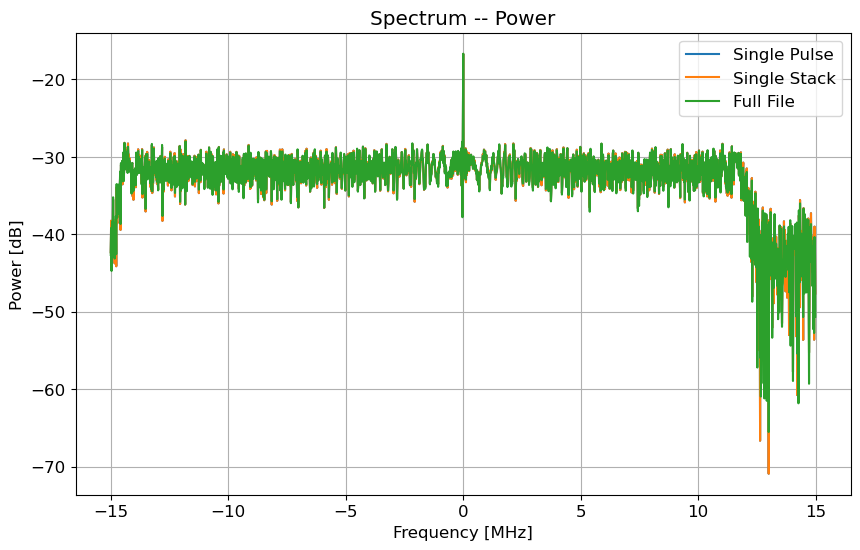

In [172]:
# fig, axs = plt.subplots(2,1)
fig, axs = plt.subplots(facecolor='white', figsize=(10,6))
freqs = np.fft.fftshift(np.fft.fftfreq(data_rx_fft_pwr.shape[0], d=1/raw.config['GENERATE']['sample_rate']))
axs.plot(freqs/1e6, np.fft.fftshift(data_rx_fft_pwr[:,0]), label='Single Pulse')
axs.plot(freqs/1e6, np.fft.fftshift(stacked_fft_pwr[:,0]), label='Single Stack')
axs.plot(freqs/1e6, np.fft.fftshift(full_fft_pwr[:,0]), label='Full File')
axs.set_xlabel('Frequency [MHz]')
axs.set_ylabel('Power [dB]')
axs.set_title('Spectrum -- Power')
axs.grid()
axs.legend()

# axs[1].plot(freqs/1e6, np.fft.fftshift(np.angle(data_rx_fft[:,0])))
# axs[1].plot(freqs/1e6, np.fft.fftshift(np.angle(stacked_fft[:,0])))
# axs[1].plot(freqs/1e6, np.fft.fftshift(np.angle(full_fft[:,0])))
# axs[1].set_xlabel('Frequency [MHz]')
# axs[1].set_ylabel('Phase [rad]')
# axs[1].set_title('Spectrum -- Phase')
# axs[1].grid()
# fig.tight_layout()